# Clinical Trials EDA
Exploratory analysis of cleaned studies from `clinical_trials.db`.

In [13]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from query import load_all

df = load_all()
print(f"{len(df):,} studies loaded")
df.head(3)

2,173 studies loaded


,nct_id,title,status,phase1,phase2,phase3,phase4,phase_text,study_type,start_date,...,enrollment,enrollment_type,masking,allocation,intervention_model,primary_purpose,locations,ingested_at,primary_outcomes,secondary_outcomes
0,NCT00923312,Trial of an RNActive®-Derived Cancer Vaccine i...,COMPLETED,1,1,0,0,PHASE1/PHASE2,INTERVENTIONAL,2009-05,...,46.0,ACTUAL,NONE,NA,SINGLE_GROUP,TREATMENT,"[{""facility"": ""RWTH Aachen"", ""city"": ""Aachen"",...",2026-05-11T22:41:17.081644+00:00,"[{""measure"": ""Phase I: Determination of the re...",[]
1,NCT00874328,A Study of TS-1 Plus Irinotecan and Cisplatin ...,UNKNOWN,1,1,0,0,PHASE1/PHASE2,INTERVENTIONAL,2008-10,...,74.0,ESTIMATED,NONE,NON_RANDOMIZED,SINGLE_GROUP,TREATMENT,"[{""facility"": ""Asan Medical Center"", ""city"": ""...",2026-05-11T22:41:17.081679+00:00,"[{""measure"": ""Evaluation the Response rate IP ...","[{""measure"": ""To estimate the time to progress..."
2,NCT00544336,Family Quality of Life Among Families With a M...,COMPLETED,0,0,0,0,None,OBSERVATIONAL,2007-08,...,366.0,ACTUAL,None,None,None,None,"[{""facility"": ""Vanderbilt-Ingram Cancer Center...",2026-05-11T22:41:17.081728+00:00,"[{""measure"": ""Preliminary validation of a fami...",[]


## Status breakdown

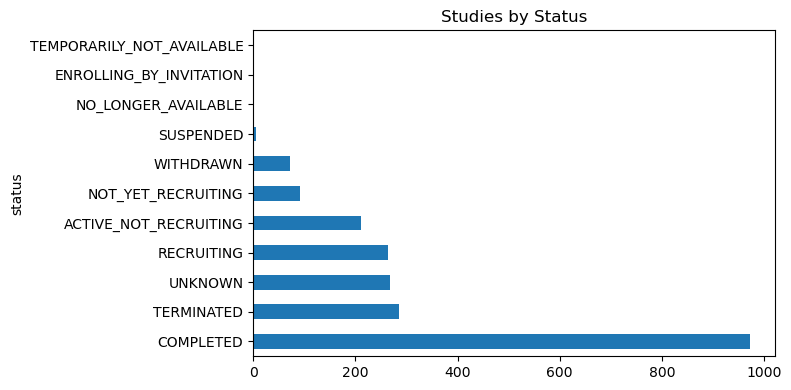

In [10]:
df['status'].value_counts().plot(kind='barh', figsize=(8, 4), title='Studies by Status')
plt.tight_layout()
plt.show()

## Phase distribution

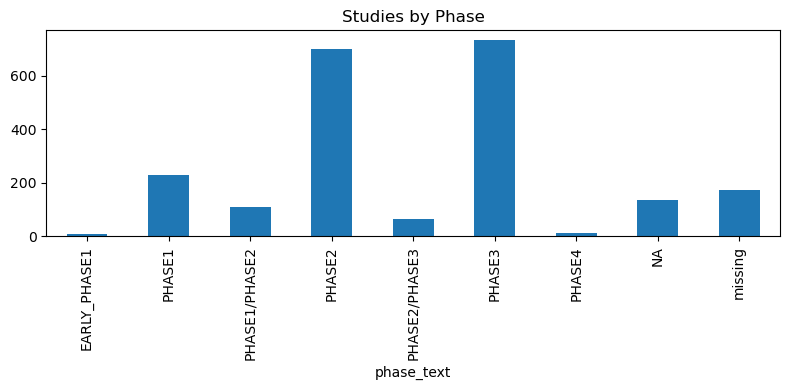

In [7]:
phase_order = ['EARLY_PHASE1', 'PHASE1', 'PHASE1/PHASE2', 'PHASE2', 'PHASE2/PHASE3', 'PHASE3', 'PHASE4', 'NA', 'missing']
assert set(df['phase_text'].dropna().unique()).issubset(set(phase_order)), "Unexpected phase values found"
assert set(phase_order).issubset(set(df['phase_text'].fillna('missing').unique())), "Phase order contains values not found in data"

counts = df['phase_text'].fillna('missing').value_counts()
counts = counts.reindex([p for p in phase_order if p in counts.index])

counts.plot(kind='bar', figsize=(8, 4), title='Studies by Phase')
plt.tight_layout()
plt.show()

## Enrollment histogram

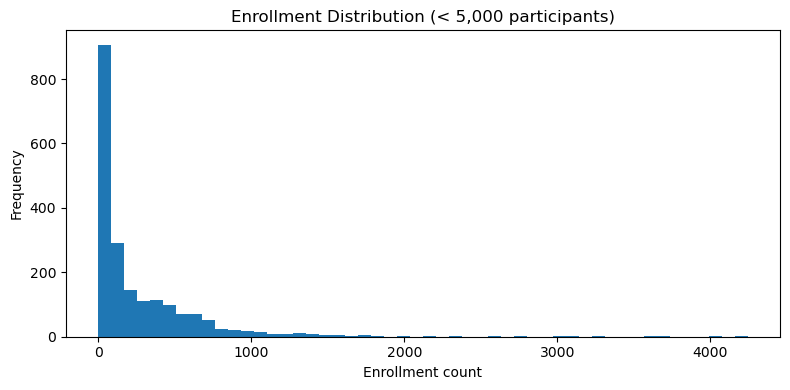

count     2079.000000
mean       270.676287
std        556.952626
min          0.000000
25%         32.000000
50%        100.000000
75%        363.500000
max      12400.000000
Name: enrollment, dtype: float64
Number of studies with 0 enrollment: 72


In [ ]:
enrollment = df['enrollment'].dropna()
enrollment[(enrollment < 5000)].plot(
    kind='hist', bins=50, figsize=(8, 4),
    title='Enrollment Distribution (< 5,000 participants)'
)
plt.xlabel('Enrollment count')
plt.tight_layout()
plt.show()
print(enrollment.describe())
print(f"Number of studies with 0 enrollment: {(enrollment == 0).sum()}")

## Trials opened per year

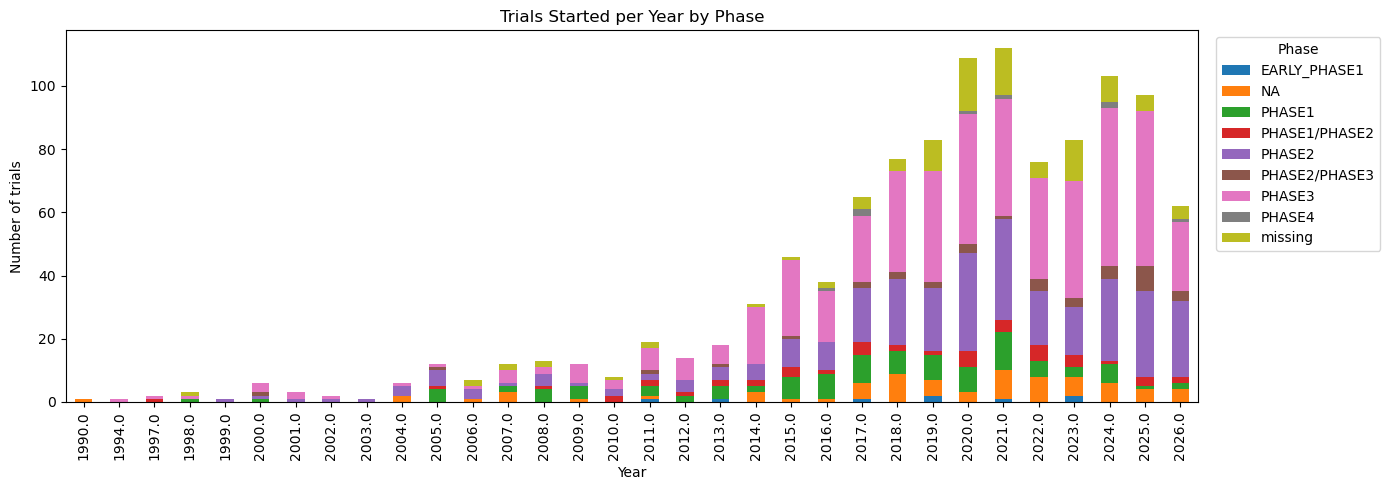

In [85]:
df['start_year'] = pd.to_datetime(df['start_date'], errors='coerce').dt.year

by_year_phase = (
    df[df['start_year'] >= 1990]
    .groupby(['start_year', df['phase_text'].fillna('missing')])
    .size()
    .unstack(fill_value=0)
)

by_year_phase.plot(kind='bar', stacked=True, figsize=(14, 5), title='Trials Started per Year by Phase')
plt.xlabel('Year')
plt.ylabel('Number of trials')
plt.legend(title='Phase', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Geographic breakdown — trials by country

87 unique countries


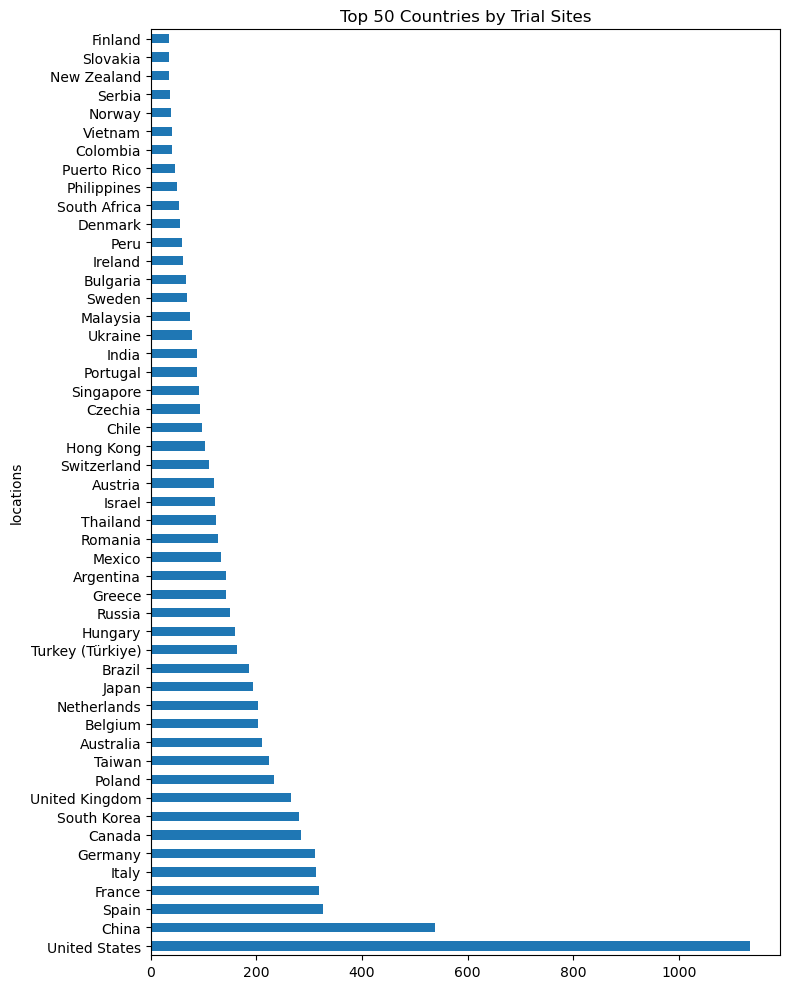

In [ ]:
# Each study can have many locations — explode them out
locs = df['locations'].dropna().apply(json.loads)
study_countries = locs.apply(lambda loc_set: {loc.get('country') for loc in loc_set}) # set of countries per study, so a country can only be counted once per study
countries = set(study_countries.explode().dropna()) # nan come from missing locations, many are widthdrawn studies with no locations
print(len(countries), "unique countries")
study_countries.explode().value_counts().head(50).plot(
    kind='barh', figsize=(8, 10), title='Top 50 Countries by Trial Sites'
)
plt.tight_layout()
plt.show()

## Geographic breakdown — US trials by state

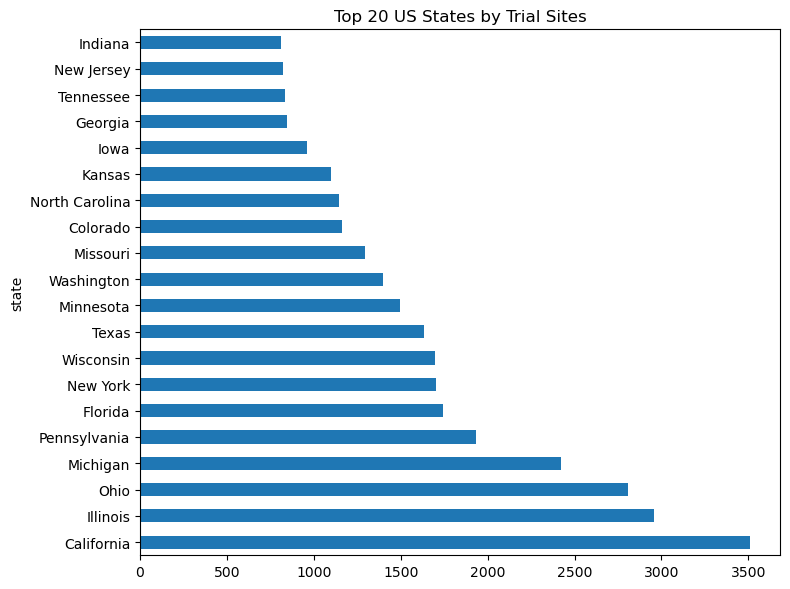

In [15]:
locs_df = pd.json_normalize(locs)
us = locs_df[locs_df['country'] == 'United States'].dropna(subset=['state'])
us['state'].value_counts().head(20).plot(
    kind='barh', figsize=(8, 6), title='Top 20 US States by Trial Sites'
)
plt.tight_layout()
plt.show()

## Sponsor class breakdown

Number of unique sponsors: 648


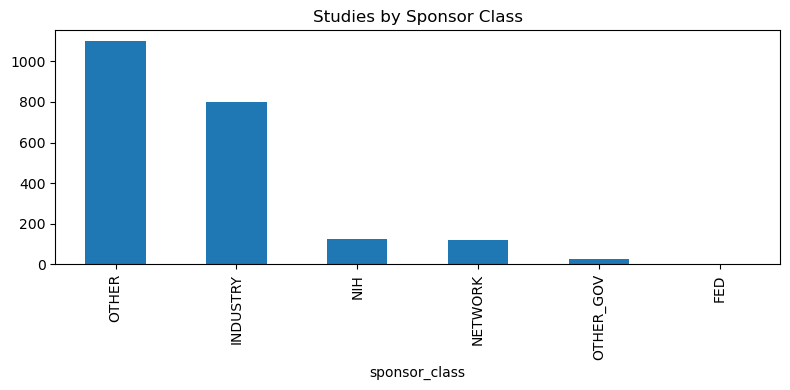

In [29]:
df['sponsor_class'].value_counts().plot(
    kind='bar', figsize=(8, 4), title='Studies by Sponsor Class'
)
# print(set(df['sponsor']))
print("Number of unique sponsors: %s" % len(set(df['sponsor'])))
plt.tight_layout()
plt.show()

## Primary and Total outcomes per study

In [26]:
# n_primary = df['primary_outcomes'].apply(lambda x: -1 if pd.isna(x) else len(json.loads(x)))
print("Number of studies without primary outcomes:", df['primary_outcomes'].isna().sum())

Number of studies without primary outcomes: 0


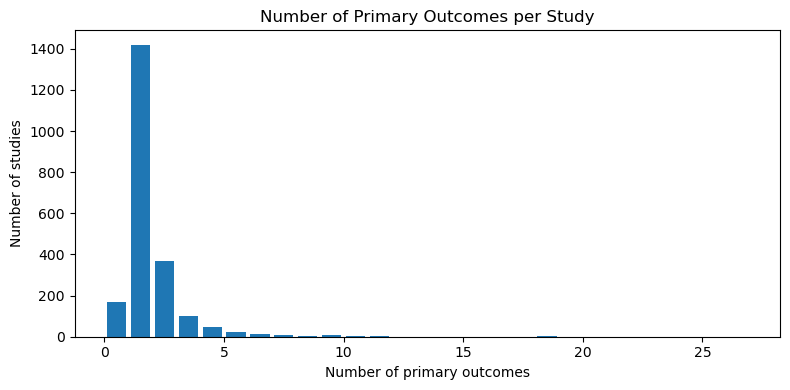

count    2173.000000
mean        1.443626
std         1.457871
min         0.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        26.000000
Name: primary_outcomes, dtype: float64


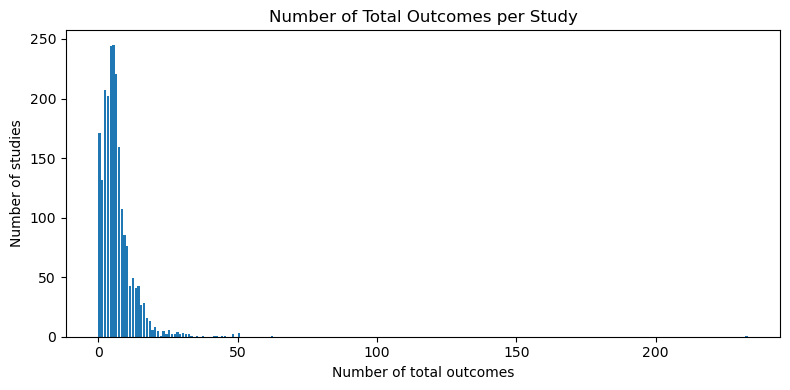

count    2173.000000
mean        6.328118
std         7.535339
min         0.000000
25%         3.000000
50%         5.000000
75%         8.000000
max       232.000000
dtype: float64


In [ ]:
n_primary = df['primary_outcomes'].apply(lambda x: len(json.loads(x)))
n_total = n_primary + df['secondary_outcomes'].dropna().apply(lambda x: len(json.loads(x)))

n_primary.plot(kind='hist', bins=range(0, n_primary.max() + 2), rwidth=0.8, figsize=(8, 4),
               title='Number of Primary Outcomes per Study', xlabel='Number of primary outcomes', ylabel='Number of studies')
plt.tight_layout()
plt.show()
print(n_primary.describe())

n_total.plot(kind='hist', bins=range(0, n_total.max() + 2), rwidth=0.8, figsize=(8, 4),
                 title='Number of Total Outcomes per Study', xlabel='Number of total outcomes', ylabel='Number of studies')
plt.tight_layout()
plt.show()
print(n_total.describe())

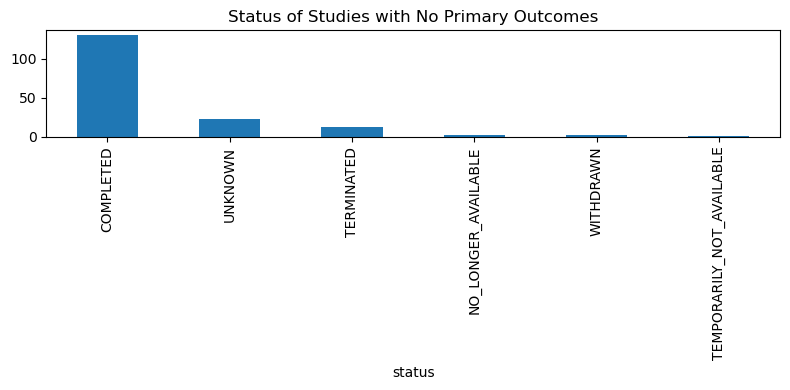

In [28]:
# no_primary = df['primary_outcomes'].apply(lambda x: len(json.loads(x)))
d = df[['primary_outcomes', 'status']].copy()
d['n_primary'] = d['primary_outcomes'].apply(lambda x: len(json.loads(x)))
d[d['n_primary'] == 0]['status'].value_counts().plot(
    kind='bar', figsize=(8, 4), title='Status of Studies with No Primary Outcomes'
)
plt.tight_layout()
plt.show()